# COVID-19 Mortality Decision Support System

## Exploratory Data Analysis, Explainable AI, and Cluster Analysis

### Introduction

This notebook builds upon the data preparation completed in the previous notebook to explore the factors associated with country-level COVID-19 mortality and to develop new analytical capabilities for the COVID-19 Decision Support System.

The primary objectives are to investigate relationships among candidate clustering variables, identify meaningful groups of similar countries using unsupervised learning, and better understand the predictions generated by the Random Forest model through explainable artificial intelligence (SHAP).

Exploratory data analysis will be used to evaluate variable distributions, relationships, missingness, and redundancy before selecting the final feature set for clustering. Principal Component Analysis (PCA) will provide additional insight into the underlying structure of the data, while K-Means clustering will be used to identify groups of countries with similar demographic, healthcare, economic, and pandemic characteristics.

Finally, SHAP (SHapley Additive exPlanations) will be applied to the trained Random Forest model to quantify the contribution of each feature to individual mortality predictions and to provide both global and country-specific explanations of model behavior.

Together, these analyses extend the predictive model developed during Capstone Two into a more transparent and interpretable decision-support system capable of providing both accurate predictions and meaningful analytical insights.

---

## Objectives

This notebook will:

- Perform exploratory data analysis of the candidate clustering variables.
- Evaluate relationships, distributions, missing values, and feature redundancy.
- Select and justify the final feature set used for clustering.
- Prepare the selected variables through imputation and feature scaling.
- Apply Principal Component Analysis (PCA) to explore the underlying structure of the data.
- Identify groups of similar countries using K-Means clustering.
- Interpret the characteristics of each country cluster.
- Explain Random Forest predictions using SHAP.
- Produce analytical assets that will be incorporated into the interactive decision-support dashboard developed in the final notebook.

In [1]:
# ---------------------------------------
# Import Libraries
# ---------------------------------------
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# ---------------------------------------
# Configure Project Paths
# ---------------------------------------

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

assert (PROJECT_ROOT / "data").exists(), (
    "Project root not found."
)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
INTERIM_DATA_DIR = DATA_DIR / "interim"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
MODEL_DIR = PROJECT_ROOT / "models"

print(f"Project: {PROJECT_ROOT.name}")

# Source Project (Capstone 2)
SOURCE_PROJECT = PROJECT_ROOT.parent / "Capstone2"

SOURCE_MODEL_DIR = SOURCE_PROJECT / "models"
SOURCE_DATA_DIR = SOURCE_PROJECT / "data"
SOURCE_PROCESSED_DATA_DIR = SOURCE_DATA_DIR / "processed"

SOURCE_REPORT_DIR = SOURCE_PROJECT / "reports"
SOURCE_FIGURE_DIR = SOURCE_REPORT_DIR / "figures"
SOURCE_TABLE_DIR = SOURCE_REPORT_DIR / "tables"

print(f"Source Project: {SOURCE_PROJECT.name}")


Project: Capstone3
Source Project: Capstone2


In [3]:
# ---------------------------------------
# Load Capstone Two Assets
# ---------------------------------------

# Load the cleaned country-level analytical dataset
analysis_df = pd.read_csv(
    SOURCE_PROCESSED_DATA_DIR / "covid_analysis_dataset.csv"
)

In [4]:
# ---------------------------------------
# Load Prepared Capstone Three Datasets
# ---------------------------------------

# Load the candidate clustering dataset created in Notebook 1.
cluster_candidate_df = pd.read_csv(
    PROCESSED_DATA_DIR / "covid_cluster_candidate_dataset.csv"
)

print(
    f"Clustering dataset loaded: "
    f"{cluster_candidate_df.shape[0]:,} countries × "
    f"{cluster_candidate_df.shape[1]:,} variables"
)

# Load the reconstructed model dataset for later use with SHAP.
model_df = pd.read_csv(
    PROCESSED_DATA_DIR / "covid_model_dataset.csv"
)

print(
    f"Model dataset loaded: "
    f"{model_df.shape[0]:,} countries × "
    f"{model_df.shape[1]:,} variables"
)

Clustering dataset loaded: 239 countries × 15 variables
Model dataset loaded: 239 countries × 12 variables


In [5]:
# ---------------------------------------
# Validate Loaded Datasets
# ---------------------------------------

assert not cluster_candidate_df.empty, (
    "The candidate clustering dataset is empty."
)

assert not model_df.empty, (
    "The reconstructed model dataset is empty."
)

assert cluster_candidate_df["country"].is_unique, (
    "Duplicate countries were found in the clustering dataset."
)

print("✓ Prepared datasets successfully loaded and validated.")

✓ Prepared datasets successfully loaded and validated.


## Exploratory Data Analysis

The exploratory analysis begins with a general review of the candidate clustering dataset. This includes examining the dataset structure, variable types, descriptive statistics, and missing-value patterns.

The purpose of this initial assessment is to identify potential data-quality concerns and better understand the range and distribution of the candidate variables before evaluating them individually.

In [6]:
# ---------------------------------------
# Inspect Candidate Clustering Dataset
# ---------------------------------------

print(
    f"Dataset dimensions: {cluster_candidate_df.shape[0]:,} countries × "
    f"{cluster_candidate_df.shape[1]:,} variables"
)

display(cluster_candidate_df.head())

cluster_candidate_df.info()

Dataset dimensions: 239 countries × 15 variables


,country,continent,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
0,Afghanistan,Asia,197.09776,16.752001,65.616997,1983.812622,0.35,81.521126,21.508444,45.270844,6.727495,61.328691,11.7,5796.4683,27.394580
1,Albania,Europe,1275.98740,35.943001,78.768799,21641.074219,2.90,465.570435,7.357504,45.244260,14.230054,90.867226,10.6,119264.5100,41.782108
2,Algeria,Africa,151.30595,27.983000,76.128899,15501.919922,1.61,208.939117,5.021889,14.251447,1.265796,18.793445,17.5,5990.6690,48.367728
3,American Samoa,Oceania,702.98770,27.927000,72.752098,NaN,NaN,NaN,NaN,NaN,NaN,246.125000,NaN,172831.6000,NaN
4,Andorra,Europe,1994.43070,42.832001,84.016403,65928.304688,NaN,3668.447510,8.646717,67.109460,54.026493,166.731915,10.1,602280.4400,33.486770


<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              239 non-null    str    
 1   continent                            239 non-null    str    
 2   total_deaths_per_million             233 non-null    float64
 3   median_age                           237 non-null    float64
 4   life_expectancy                      237 non-null    float64
 5   gdp_per_capita                       199 non-null    float64
 6   hospital_beds_per_thousand           168 non-null    float64
 7   health_expenditure_per_capita        192 non-null    float64
 8   health_expenditure_pct_gdp           193 non-null    float64
 9   people_fully_vaccinated_per_hundred  215 non-null    float64
 10  total_boosters_per_hundred           208 non-null    float64
 11  population_density                   215 no

In [7]:
# ---------------------------------------
# Summarize Candidate Variables
# ---------------------------------------

# Exclude country and continent because the initial statistical summary
# is intended to describe the continuous clustering candidates.
candidate_feature_columns = cluster_candidate_df.select_dtypes(
    include="number"
).columns.tolist()

candidate_summary_df = (
    cluster_candidate_df[candidate_feature_columns]
    .describe()
    .T
    .rename(
        columns={
            "count": "Count",
            "mean": "Mean",
            "std": "Standard Deviation",
            "min": "Minimum",
            "25%": "25th Percentile",
            "50%": "Median",
            "75%": "75th Percentile",
            "max": "Maximum",
        }
    )
)

display(candidate_summary_df.round(2))

,Count,Mean,Standard Deviation,Minimum,25th Percentile,Median,75th Percentile,Maximum
total_deaths_per_million,233.0,1276.36,1338.19,0.00,141.10,889.35,2023.35,6603.98
median_age,237.0,31.21,9.74,14.30,22.24,31.70,39.08,59.88
life_expectancy,237.0,73.45,7.74,18.82,68.75,74.70,79.04,85.75
gdp_per_capita,199.0,27832.98,27210.58,1051.26,6809.08,18068.51,42513.20,132569.53
hospital_beds_per_thousand,168.0,2.98,2.77,0.15,1.09,2.38,3.94,21.99
health_expenditure_per_capita,192.0,1407.31,2323.67,15.02,94.35,422.35,1418.75,12080.07
health_expenditure_pct_gdp,193.0,7.14,3.17,2.15,4.79,6.64,9.15,21.51
people_fully_vaccinated_per_hundred,215.0,57.10,24.44,0.27,39.36,62.44,75.93,110.19
total_boosters_per_hundred,208.0,34.45,31.12,0.00,7.72,28.42,56.29,140.53
population_density,215.0,445.30,2017.25,0.14,39.25,91.96,234.66,20681.82


In [8]:
# ---------------------------------------
# Define Candidate Clustering Variables
# ---------------------------------------

# These variables are candidates for the clustering analysis.
# The mortality outcome is intentionally excluded because it will
# be used to interpret the clusters rather than create them.
cluster_features = [
    "median_age",
    "life_expectancy",
    "gdp_per_capita",
    "hospital_beds_per_thousand",
    "health_expenditure_per_capita",
    "health_expenditure_pct_gdp",
    "people_fully_vaccinated_per_hundred",
    "total_boosters_per_hundred",
    "population_density",
    "diabetes_prevalence",
    "total_cases_per_million",
    "stringency_index",
]

### Variable Distributions

Understanding the distribution of each candidate clustering variable is an important step in exploratory data analysis. Histograms provide insight into the range, central tendency, skewness, and potential outliers of each variable.

Variables exhibiting substantial skewness or extreme values may require transformation prior to clustering, while approximately symmetric variables can typically be used directly after imputation and feature scaling.

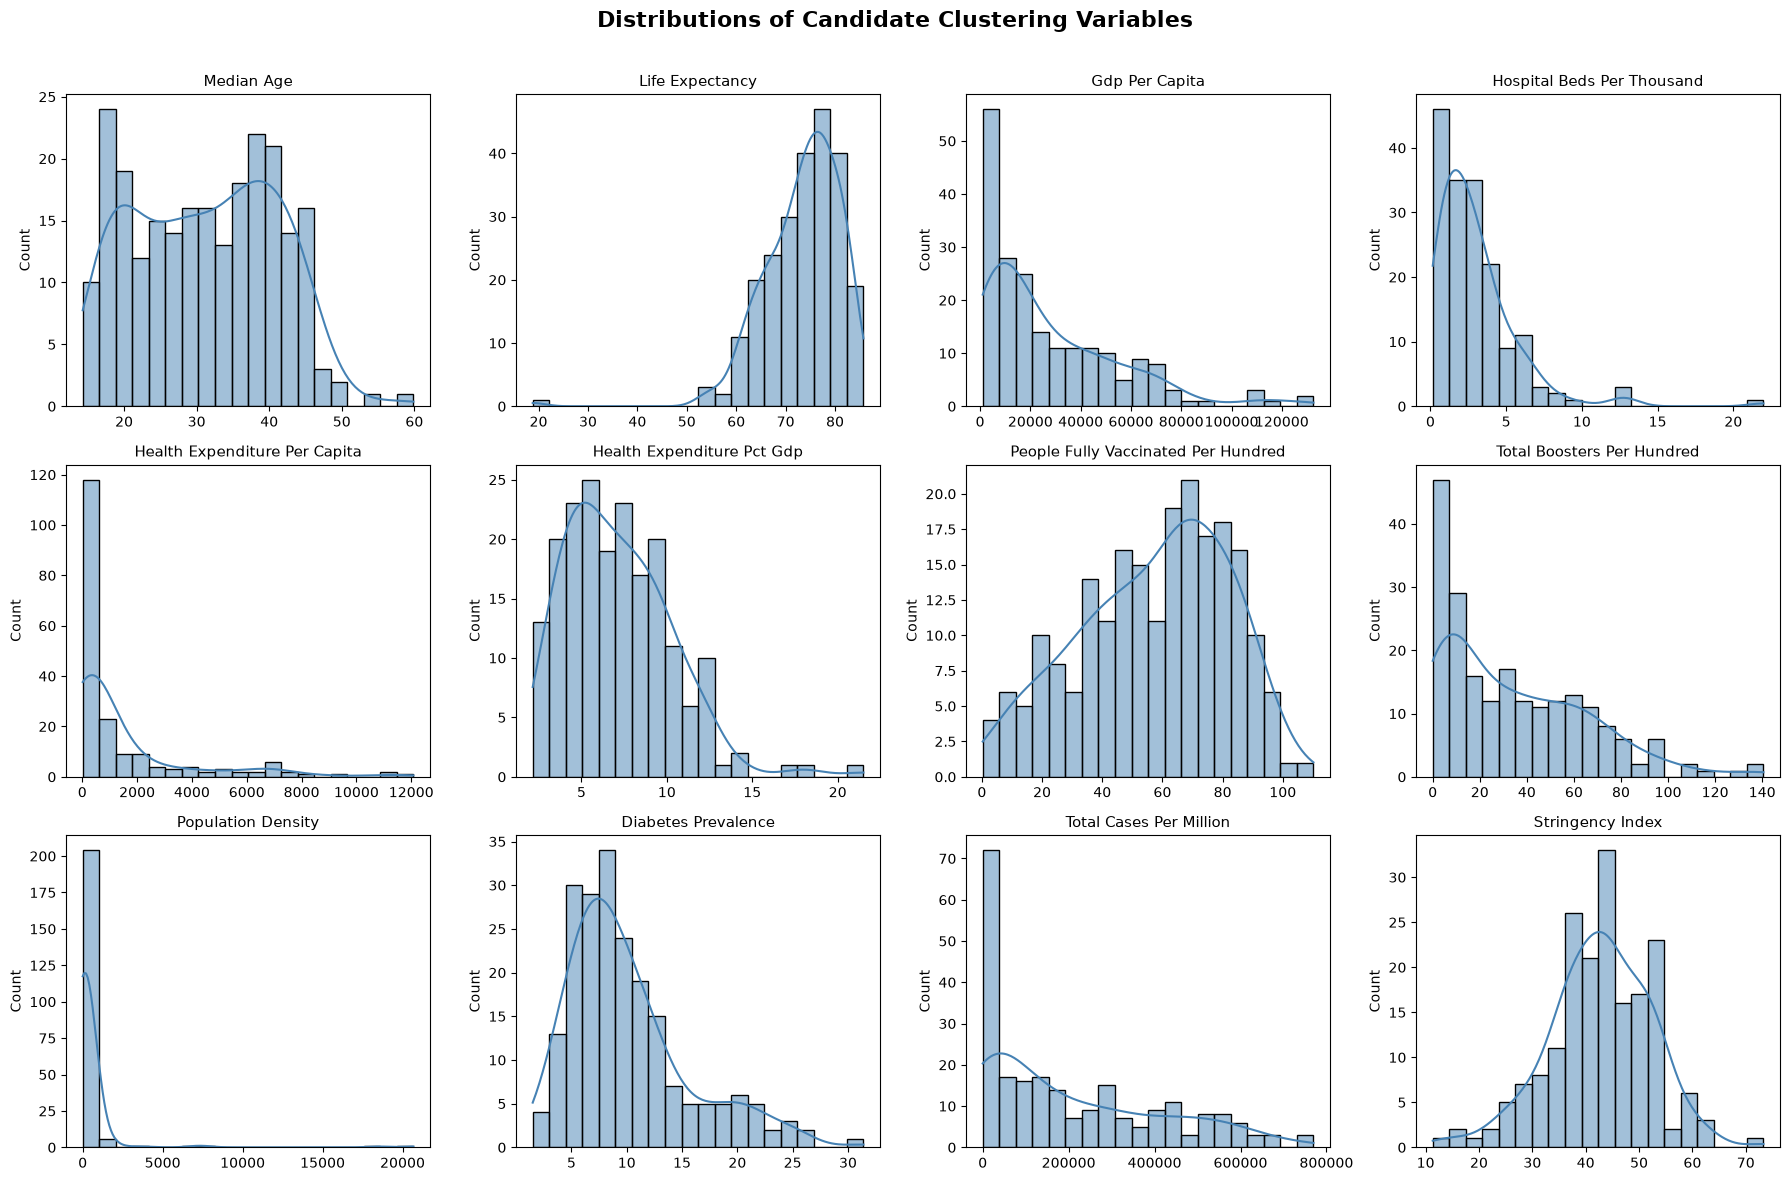

In [9]:
# ---------------------------------------
# Plot Variable Distributions
# ---------------------------------------

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, feature in zip(axes, cluster_features):

    sns.histplot(
        data=cluster_candidate_df,
        x=feature,
        bins=20,
        kde=True,
        ax=ax,
        color="steelblue"
    )

    ax.set_title(feature.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.suptitle(
    "Distributions of Candidate Clustering Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

### Interpretation

The distributions reveal substantial heterogeneity across countries for nearly all variables. Demographic measures such as median age and life expectancy are approximately unimodal but exhibit broad ranges, reflecting differences in population structure and development. Economic and healthcare variables, including GDP per capita, hospital beds per thousand, and health expenditure, are strongly right-skewed, with a relatively small number of high-income countries possessing substantially greater resources than the global median.

COVID-19 measures, including cases per million, deaths per million, vaccination coverage, and booster uptake, also display considerable variability. While many countries experienced relatively low reported case and mortality rates, others reported substantially higher values, producing long right tails. These patterns highlight the diversity of pandemic experiences across countries and suggest that appropriate statistical methods capable of handling skewed distributions and nonlinear relationships will be important for subsequent modeling.

### Correlation Analysis

Correlation analysis helps identify relationships among the candidate clustering variables. Strong correlations may indicate that two variables capture similar underlying information, suggesting that one of them could potentially be removed to reduce redundancy in the clustering model.

The correlation matrix is used here as an exploratory tool rather than a strict selection criterion. Decisions regarding the final clustering variables will also consider domain knowledge, interpretability, and the overall objectives of the analysis.

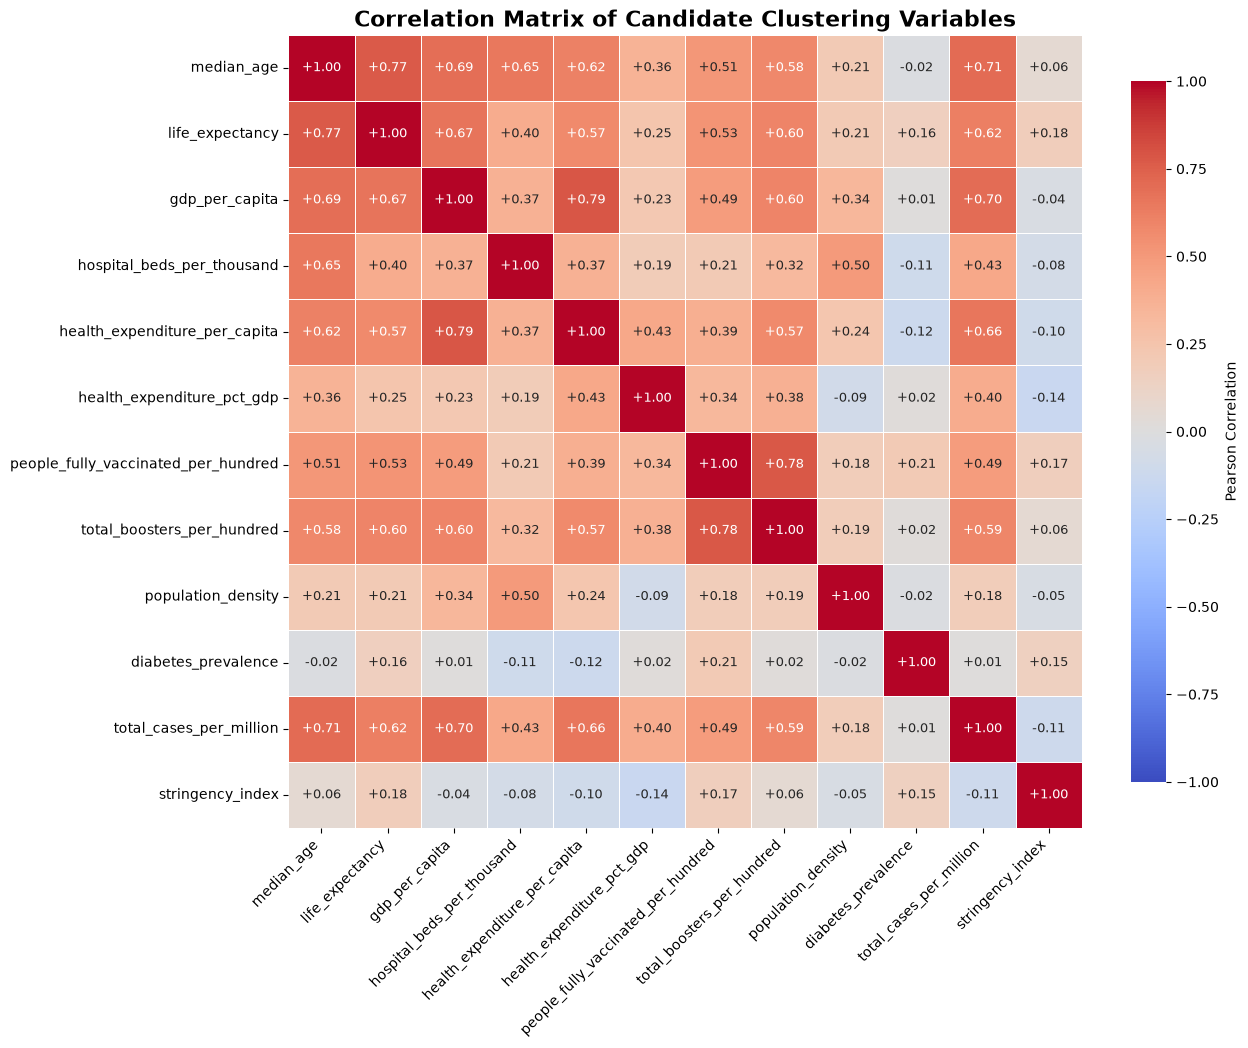

In [10]:
# ---------------------------------------
# Correlation Heatmap
# ---------------------------------------

# Compute pairwise Pearson correlations among the candidate
# clustering variables.
correlation_matrix = (
    cluster_candidate_df[cluster_features]
    .corr(numeric_only=True)
)

plt.figure(figsize=(13, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt="+.2f",
    annot_kws={"size": 9},
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
)

plt.title(
    "Correlation Matrix of Candidate Clustering Variables",
    fontsize=16,
    fontweight="bold",
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Correlation Observations

The candidate clustering variables exhibited primarily positive correlations, with relatively few meaningful negative relationships. Several variables associated with national development, population age, healthcare resources, vaccination, and reported case burden moved together.

The strongest correlations were observed between GDP per capita and health expenditure per capita, full vaccination and booster coverage, and median age and life expectancy. These relationships suggest potential redundancy within the candidate feature set. Including multiple highly correlated variables could cause these shared dimensions to exert disproportionate influence on the clustering solution.

In contrast, diabetes prevalence and the government stringency index showed relatively weak correlations with most other variables, indicating that they may contribute more distinct information. The correlation matrix will therefore be used to guide feature selection, with the goal of retaining interpretable variables while limiting unnecessary duplication.

## Clustering Feature Selection

The objective of the clustering analysis is to identify meaningful groups of countries based on demographic, healthcare, economic, vaccination, and pandemic-related characteristics. Because highly correlated variables can disproportionately influence distance-based clustering methods such as K-Means, the candidate variables were evaluated for redundancy before constructing the final clustering feature set.

Variable selection was based on multiple considerations, including:

- Pairwise correlations among candidate variables.
- Interpretability of the variables.
- Data completeness.
- The potential contribution of each variable to distinguishing countries.

Rather than applying a strict correlation threshold, variables were evaluated individually to balance statistical considerations with domain knowledge.

## Clustering Feature Selection

The objective of the clustering analysis was to group countries according to characteristics that may have influenced their COVID-19 experience rather than the pandemic outcomes themselves. Consequently, variables representing demographics, economic development, healthcare capacity, population health, and national pandemic response were selected, while outcome measures such as COVID-19 cases and deaths were intentionally excluded from the clustering process. This approach allows the resulting clusters to be evaluated afterward to determine whether countries with similar underlying characteristics experienced different pandemic outcomes.

Candidate variables were evaluated using three primary criteria:

- Relevance to the underlying characteristics of a country.
- Redundancy with other candidate variables based on the correlation analysis.
- Interpretability and usefulness for describing country-level differences.

Several variables were excluded despite showing strong relationships with COVID-19 outcomes. Life expectancy was omitted because it is largely a downstream measure reflecting the combined effects of demographics, healthcare, and socioeconomic conditions, whereas median age provides a more direct measure of population age structure. Health expenditure per capita was excluded because it was strongly correlated with GDP per capita and may also reflect differences in healthcare costs and system efficiency rather than healthcare capacity alone. People fully vaccinated per hundred was retained in place of booster coverage because it provided a more complete and easily interpretable measure of national vaccination response. Finally, COVID-19 cases and deaths per million were excluded because they represent outcomes that were later used to characterize and compare the resulting clusters rather than define them.

Based on these considerations, the final clustering feature set consisted of:

- Median Age
- GDP per Capita
- Hospital Beds per Thousand
- Health Expenditure (% GDP)
- Population Density
- Diabetes Prevalence
- People Fully Vaccinated per Hundred
- Stringency Index

In [65]:
# ---------------------------------------
# Evaluate Candidate Clustering Variables
# ---------------------------------------


feature_selection_df = pd.DataFrame({
    "Feature": [
        "Median Age",
        "GDP per Capita",
        "Hospital Beds per Thousand",
        "People Fully Vaccinated per Hundred",
        "Population Density",
        "Life Expectancy",
        "Total Cases per Million",
        "Total Deaths per Million",
        "Stringency Index",
        "Booster Doses per Hundred",
        "Human Development Index",
        "Health Expenditure per Capita",
    ],
    "Decision": [
        "Included",
        "Included",
        "Included",
        "Included",
        "Included",
        "Included",
        "Included",
        "Excluded",
        "Excluded",
        "Excluded",
        "Excluded",
        "Excluded",
    ],
    "Rationale": [
        "Represents population age structure.",
        "Captures economic development and available resources.",
        "Measures healthcare system capacity.",
        "Represents vaccination coverage.",
        "Captures urbanization and potential disease transmission.",
        "Summarizes overall population health.",
        "Reflects the overall burden of COVID-19 experienced by each country.",
        "Outcome variable reserved for evaluating clusters rather than defining them.",
        "Government policy measure that reflects intervention rather than intrinsic country characteristics.",
        "Highly correlated with full vaccination coverage; excluded to reduce redundancy.",
        "Largely redundant with GDP per capita and life expectancy.",
        "Closely related to GDP and healthcare capacity, providing limited additional information.",
    ]
})

display(feature_selection_df)

,Feature,Decision,Rationale
0,Median Age,Included,Represents population age structure.
1,GDP per Capita,Included,Captures economic development and available re...
2,Hospital Beds per Thousand,Included,Measures healthcare system capacity.
3,People Fully Vaccinated per Hundred,Included,Represents vaccination coverage.
4,Population Density,Included,Captures urbanization and potential disease tr...
5,Life Expectancy,Included,Summarizes overall population health.
6,Total Cases per Million,Included,Reflects the overall burden of COVID-19 experi...
7,Total Deaths per Million,Excluded,Outcome variable reserved for evaluating clust...
8,Stringency Index,Excluded,Government policy measure that reflects interv...
9,Booster Doses per Hundred,Excluded,Highly correlated with full vaccination covera...


### Missing Data

Missing values were evaluated for each candidate clustering variable before preprocessing. Although several variables contained moderate levels of missingness, no variable was excluded solely on this basis. Instead, variable selection considered relevance to the clustering objective, redundancy with other predictors, and interpretability. Missing values in the final feature set were subsequently addressed using median imputation.

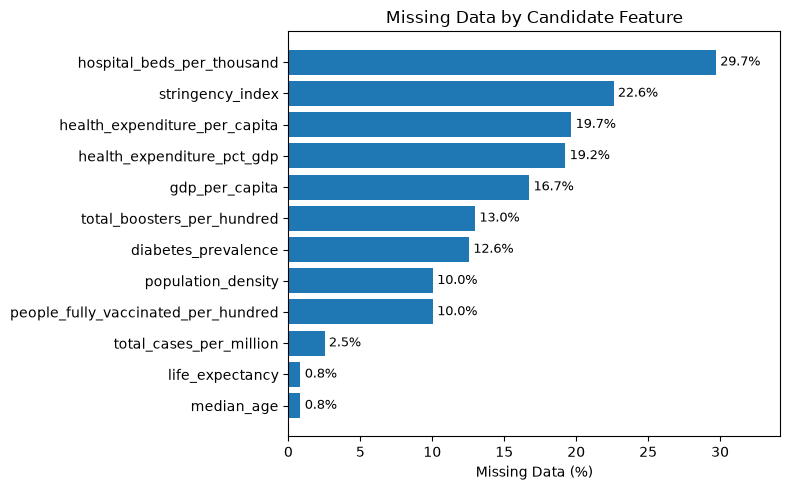

In [12]:
# ---------------------------------------
# Missing Data by Variable
# ---------------------------------------

missing_pct = (
    cluster_candidate_df[cluster_features]
    .isna()
    .mean()
    .sort_values(ascending=True) * 100
)

plt.figure(figsize=(8, 5))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Missing Data (%)")
plt.title("Missing Data by Candidate Feature")

plt.xlim(0, max(missing_pct.values) * 1.15)

for i, value in enumerate(missing_pct.values):
    plt.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Interpretation

Missing data varied across the candidate clustering variables, ranging from less than 1% for median age and life expectancy to approximately 30% for hospital beds per thousand. Although several healthcare- and policy-related variables exhibited moderate missingness, no variable was excluded solely because of incomplete data. Instead, variable selection was based primarily on relevance to the clustering objective and interpretability. Missing values in the final feature set were subsequently addressed using median imputation.

# Data Preprocessing

Prior to clustering, the selected features were prepared to ensure they were suitable for distance-based machine learning methods. Missing values were replaced using median imputation to preserve all countries in the analysis while minimizing the influence of outliers. Because the selected variables were measured on substantially different scales (e.g., GDP per capita, population density, and vaccination rates), all features were subsequently standardized to have a mean of zero and a standard deviation of one. Standardization prevents variables with larger numeric ranges from disproportionately influencing the clustering algorithm.

In [13]:
# ---------------------------------------
# Final Clustering Feature Set
# ---------------------------------------

cluster_features = [
    "median_age",
    "gdp_per_capita",
    "hospital_beds_per_thousand",
    "health_expenditure_pct_gdp",
    "population_density",
    "diabetes_prevalence",
    "people_fully_vaccinated_per_hundred",
    "stringency_index",
]

X_cluster = cluster_candidate_df[cluster_features].copy()

display(X_cluster.head())

,median_age,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_pct_gdp,population_density,diabetes_prevalence,people_fully_vaccinated_per_hundred,stringency_index
0,16.752001,1983.812622,0.35,21.508444,61.328691,11.7,45.270844,27.394580
1,35.943001,21641.074219,2.90,7.357504,90.867226,10.6,45.244260,41.782108
2,27.983000,15501.919922,1.61,5.021889,18.793445,17.5,14.251447,48.367728
3,27.927000,NaN,NaN,NaN,246.125000,NaN,NaN,NaN
4,42.832001,65928.304688,NaN,8.646717,166.731915,10.1,67.109460,33.486770


In [14]:
# ---------------------------------------
# Additional Imports
# ---------------------------------------

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [15]:
# ---------------------------------------
# Median Imputation
# ---------------------------------------

cluster_imputer = SimpleImputer(strategy="median")

X_cluster_imputed = pd.DataFrame(
    cluster_imputer.fit_transform(X_cluster),
    columns=cluster_features,
    index=X_cluster.index,
)

display(X_cluster_imputed.isna().sum())

median_age                             0
gdp_per_capita                         0
hospital_beds_per_thousand             0
health_expenditure_pct_gdp             0
population_density                     0
diabetes_prevalence                    0
people_fully_vaccinated_per_hundred    0
stringency_index                       0
dtype: int64

In [16]:
# ---------------------------------------
# Feature Standardization
# ---------------------------------------

cluster_scaler = StandardScaler()

X_cluster_scaled = pd.DataFrame(
    cluster_scaler.fit_transform(X_cluster_imputed),
    columns=cluster_features,
    index=X_cluster.index,
)

display(X_cluster_scaled.head())



,median_age,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_pct_gdp,population_density,diabetes_prevalence,people_fully_vaccinated_per_hundred,stringency_index
0,-1.494760,-0.967294,-1.049479,5.081167,-0.182285,0.350606,-0.533518,-1.822009
1,0.488936,-0.182062,0.043284,0.110196,-0.166834,0.137338,-0.534665,-0.121540
2,-0.333857,-0.427298,-0.509525,-0.710263,-0.204534,1.475108,-1.871833,0.656817
3,-0.339646,-0.324772,-0.179554,-0.142021,-0.085623,-0.269809,0.207249,0.054673
4,1.201025,1.587043,-0.179554,0.563074,-0.127152,0.040398,0.408696,-1.101970


In [17]:
joblib.dump(cluster_imputer, MODEL_DIR / "cluster_imputer.joblib")
joblib.dump(cluster_scaler, MODEL_DIR / "cluster_scaler.joblib")
joblib.dump(cluster_features, MODEL_DIR / "cluster_features.joblib")

['/Users/papa/Desktop/Springboard/Capstone3/models/cluster_features.joblib']

Principal Component Analysis (PCA) was performed to examine the underlying structure of the selected clustering features and to reduce the dimensionality of the dataset. PCA transforms correlated variables into a smaller set of orthogonal principal components while preserving as much of the original variance as possible.

The analysis serves two purposes:

- To determine whether a small number of principal components adequately summarize the selected variables.
- To provide a low-dimensional representation of the countries for visualization prior to clustering.

In [18]:
# ---------------------------------------
# Principal Component Analysis
# ---------------------------------------

pca = PCA(random_state=42)

X_pca = pca.fit_transform(X_cluster_scaled)

In [19]:
explained_variance_df = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(cluster_features))
    ],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained_variance_df)

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.312789,0.312789
1,PC2,0.162478,0.475267
2,PC3,0.140184,0.615451
3,PC4,0.112599,0.728050
4,PC5,0.094707,0.822757
5,PC6,0.080111,0.902867
6,PC7,0.059833,0.962700
7,PC8,0.037300,1.000000


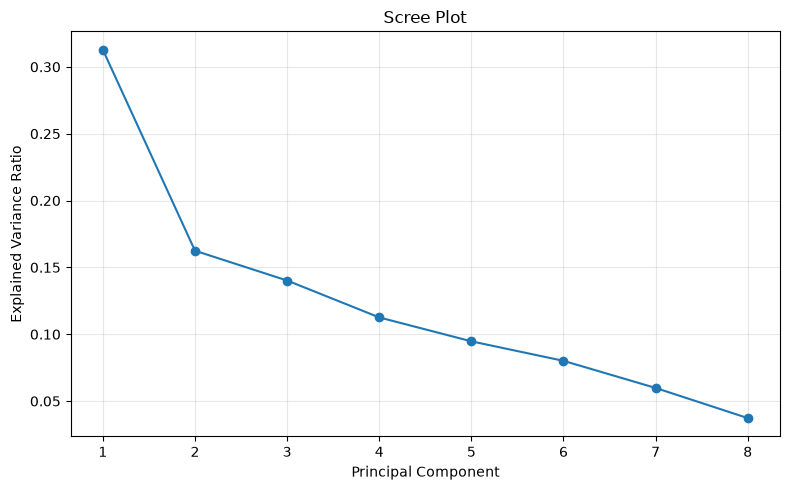

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cluster_features)+1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.xticks(range(1, len(cluster_features)+1))

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
cluster_candidate_df.head()


,country,continent,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
0,Afghanistan,Asia,197.09776,16.752001,65.616997,1983.812622,0.35,81.521126,21.508444,45.270844,6.727495,61.328691,11.7,5796.4683,27.394580
1,Albania,Europe,1275.98740,35.943001,78.768799,21641.074219,2.90,465.570435,7.357504,45.244260,14.230054,90.867226,10.6,119264.5100,41.782108
2,Algeria,Africa,151.30595,27.983000,76.128899,15501.919922,1.61,208.939117,5.021889,14.251447,1.265796,18.793445,17.5,5990.6690,48.367728
3,American Samoa,Oceania,702.98770,27.927000,72.752098,NaN,NaN,NaN,NaN,NaN,NaN,246.125000,NaN,172831.6000,NaN
4,Andorra,Europe,1994.43070,42.832001,84.016403,65928.304688,NaN,3668.447510,8.646717,67.109460,54.026493,166.731915,10.1,602280.4400,33.486770


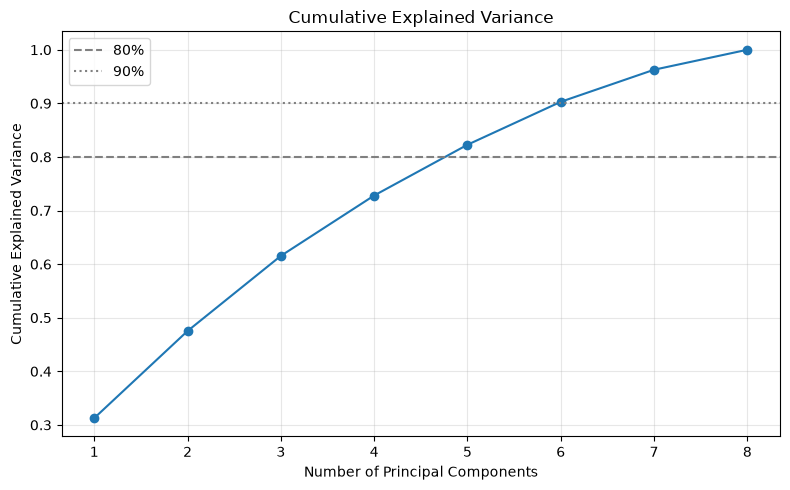

In [22]:
# ---------------------------------------
# Cumulative Explained Variance
# ---------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cluster_features) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(0.80, color="gray", linestyle="--", label="80%")
plt.axhline(0.90, color="gray", linestyle=":", label="90%")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.xticks(range(1, len(cluster_features) + 1))

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ---------------------------------------
# PCA Loadings
# ---------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=[f"PC{i+1}" for i in range(len(cluster_features))]
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
median_age,0.536,-0.009,0.036,-0.236,0.019,-0.316,0.056,0.744
gdp_per_capita,0.471,0.022,-0.010,0.068,-0.547,-0.283,-0.494,-0.386
hospital_beds_per_thousand,0.391,-0.339,-0.175,-0.090,0.651,-0.252,0.116,-0.438
health_expenditure_pct_gdp,0.281,0.068,0.675,0.038,0.307,0.486,-0.359,0.003
population_density,0.263,-0.281,-0.572,0.390,-0.023,0.554,-0.150,0.206
diabetes_prevalence,0.018,0.600,-0.093,0.648,0.321,-0.300,-0.109,0.076
people_fully_vaccinated_per_hundred,0.436,0.381,0.046,0.024,-0.218,0.281,0.695,-0.231
stringency_index,0.010,0.544,-0.418,-0.598,0.176,0.208,-0.306,-0.063


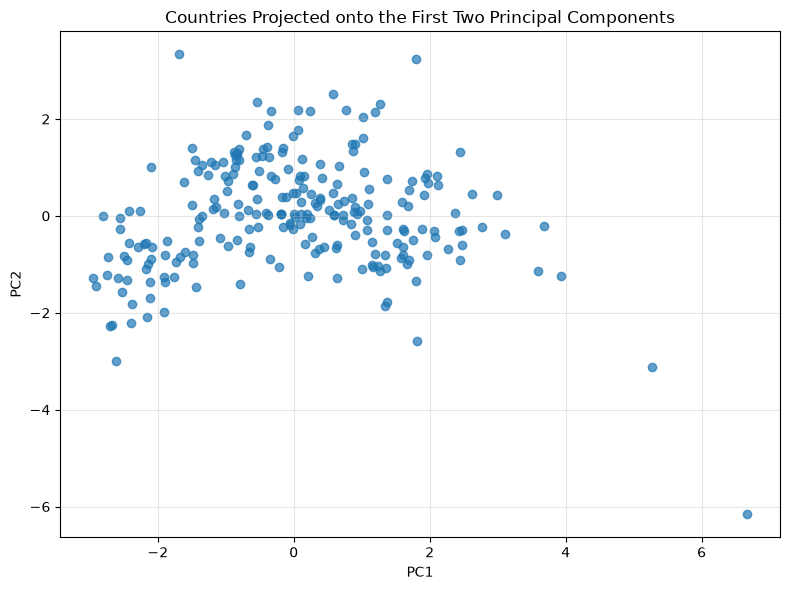

In [24]:
scores = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

plt.figure(figsize=(8,6))

plt.scatter(
    scores["PC1"],
    scores["PC2"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Countries Projected onto the First Two Principal Components")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# K-Means Clustering

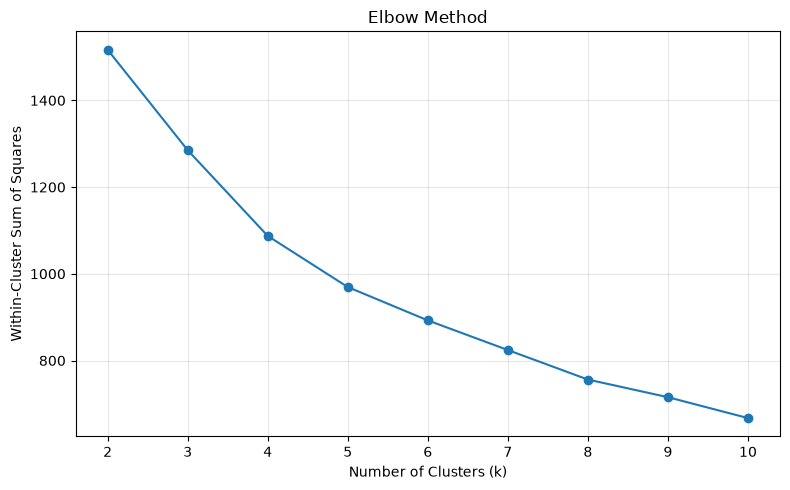

In [25]:
# ---------------------------------------
# Elbow Method
# ---------------------------------------

inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")

plt.title("Elbow Method")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

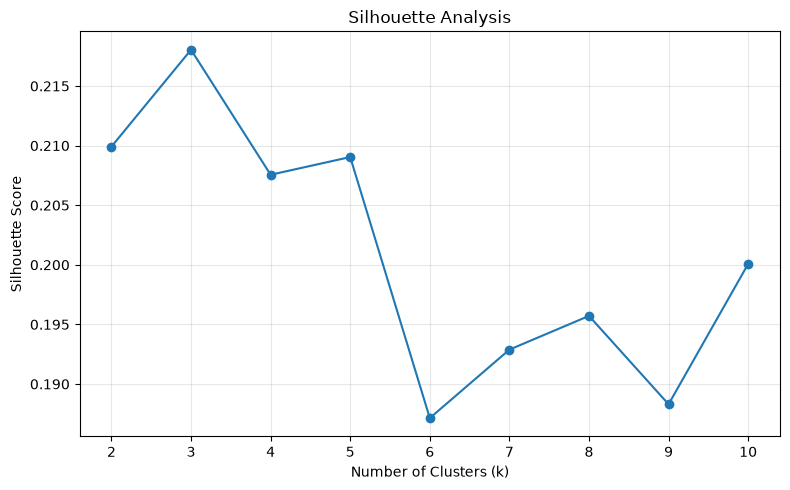

In [26]:
# ---------------------------------------
# Silhouette Analysis
# ---------------------------------------

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster_scaled)

    silhouette_scores.append(
        silhouette_score(
            X_cluster_scaled,
            labels
        )
    )

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Selecting the Number of Clusters

The optimal number of clusters was evaluated using both the Elbow Method and Silhouette Analysis. Because the two methods suggested slightly different solutions, both three- and four-cluster models were examined. The final choice was based on a combination of clustering quality and interpretability.

In [27]:
# ---------------------------------------
# K-Means Clustering (k = 3)
# ---------------------------------------

kmeans3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels3 = kmeans3.fit_predict(X_cluster_scaled)

In [28]:
cluster_results3 = cluster_candidate_df.copy()

cluster_results3["Cluster"] = cluster_labels3

In [29]:
cluster_results3["Cluster"].value_counts().sort_index()

Cluster
0    120
1    117
2      2
Name: count, dtype: int64

In [30]:
cluster_summary3 = (
    cluster_results3
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

display(cluster_summary3)

,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
Cluster,,,,,,,,,,,,,
0,661.75,23.27,68.50,9904.65,1.52,229.02,5.99,44.40,17.29,142.80,10.3,64632.84,43.86
1,1897.80,38.96,78.26,47577.99,4.32,2890.42,8.70,70.25,52.55,406.98,9.9,352536.72,41.43
2,1720.15,46.40,83.92,111693.50,21.99,8225.39,3.67,78.54,56.93,19584.43,7.5,441103.97,35.07


In [31]:
# ---------------------------------------
# K-Means Clustering (k = 4)
# ---------------------------------------

kmeans4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels4 = kmeans4.fit_predict(X_cluster_scaled)

In [32]:
# ---------------------------------------
# Candidate K-Means Clustering (k = 4)
# ---------------------------------------

cluster_results4 = cluster_candidate_df.copy()

cluster_results4["Cluster"] = cluster_labels4

In [33]:
cluster_results4["Cluster"].value_counts().sort_index()

Cluster
0     72
1     57
2    108
3      2
Name: count, dtype: int64

In [34]:
cluster_summary4 = (
    cluster_results4
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

display(cluster_summary4)

,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
Cluster,,,,,,,,,,,,,
0,2364.20,41.77,79.11,55112.57,4.88,3856.32,9.35,68.34,57.34,421.26,7.92,398418.90,39.74
1,238.82,19.45,64.05,5572.11,1.34,111.07,5.67,31.44,8.39,92.30,6.98,17626.27,36.71
2,1101.92,30.08,74.46,21256.72,2.23,626.50,6.73,64.40,34.08,261.08,13.75,181390.29,49.60
3,1720.15,46.40,83.92,111693.50,21.99,8225.39,3.67,78.54,56.93,19584.43,7.50,441103.97,35.07


In [35]:
cluster_results4.loc[
    cluster_results4["Cluster"] == 3,
    ["country"]
]

,country
123,Macao
138,Monaco


## Outlier Assessment and Final Clustering Dataset

The initial three- and four-cluster solutions consistently isolated Monaco and Macao into a cluster containing only two observations. Both locations have highly unusual combinations of population density, economic resources, healthcare capacity, and demographic characteristics relative to the rest of the dataset. As a result, they exerted substantial influence on the K-Means solution and reduced the algorithm's ability to identify meaningful structure among the remaining countries.

Monaco and Macao were therefore excluded from the final K-Means analysis and retained separately as outlier observations. The clustering preprocessing steps—median imputation and standardization—were repeated using only the remaining countries to prevent the excluded observations from influencing the imputation values, scaling parameters, or cluster centroids.

The number of clusters was then reevaluated using the filtered dataset.

In [36]:
# ---------------------------------------
# Remove Influential Outliers
# ---------------------------------------

outlier_countries = ["Macao", "Monaco"]

cluster_analysis_df = cluster_candidate_df.loc[
    ~cluster_candidate_df["country"].isin(outlier_countries)
].copy()

cluster_outliers = cluster_candidate_df.loc[
    cluster_candidate_df["country"].isin(outlier_countries)
].copy()

print(f"Countries retained for clustering: {len(cluster_analysis_df)}")
print(f"Countries retained as outliers: {len(cluster_outliers)}")

display(cluster_outliers)

Countries retained for clustering: 237
Countries retained as outliers: 2


,country,continent,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
123,Macao,Asia,NaN,37.831001,82.102501,111693.5,NaN,NaN,NaN,91.18433,68.291214,20681.818182,8.1,NaN,33.347536
138,Monaco,Europe,1720.154,54.974998,85.746399,NaN,21.99,8225.387695,3.674946,65.89730,45.563540,18487.044146,6.9,441103.97,36.800675


In [37]:
# ---------------------------------------
# Refit Clustering Preprocessing
# ---------------------------------------

X_cluster_final = cluster_analysis_df[cluster_features].copy()

final_cluster_imputer = SimpleImputer(strategy="median")

X_cluster_imputed_final = pd.DataFrame(
    final_cluster_imputer.fit_transform(X_cluster_final),
    columns=cluster_features,
    index=X_cluster_final.index,
)

final_cluster_scaler = StandardScaler()

X_cluster_scaled_final = pd.DataFrame(
    final_cluster_scaler.fit_transform(X_cluster_imputed_final),
    columns=cluster_features,
    index=X_cluster_imputed_final.index,
)

print(
    "Remaining missing values:",
    X_cluster_scaled_final.isna().sum().sum()
)

display(X_cluster_scaled_final.head())

Remaining missing values: 0


,median_age,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_pct_gdp,population_density,diabetes_prevalence,people_fully_vaccinated_per_hundred,stringency_index
0,-1.495904,-0.973241,-1.193551,5.069165,-0.252415,0.345573,-0.520815,-1.829090
1,0.507083,-0.171510,0.092367,0.103376,-0.212468,0.132994,-0.521964,-0.129471
2,-0.323711,-0.421898,-0.558156,-0.716229,-0.309940,1.466441,-1.861297,0.648498
3,-0.329556,-0.323683,-0.174903,-0.142686,-0.002498,-0.272838,0.162449,0.047879
4,1.226096,1.634767,-0.174903,0.555781,-0.109869,0.036368,0.422926,-1.109411


In [38]:
# ---------------------------------------
# Reevaluate Number of Clusters
# ---------------------------------------

k_values_final = range(2, 11)

final_inertia = []
final_silhouette_scores = []

for k in k_values_final:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_cluster_scaled_final)

    final_inertia.append(model.inertia_)
    final_silhouette_scores.append(
        silhouette_score(X_cluster_scaled_final, labels)
    )

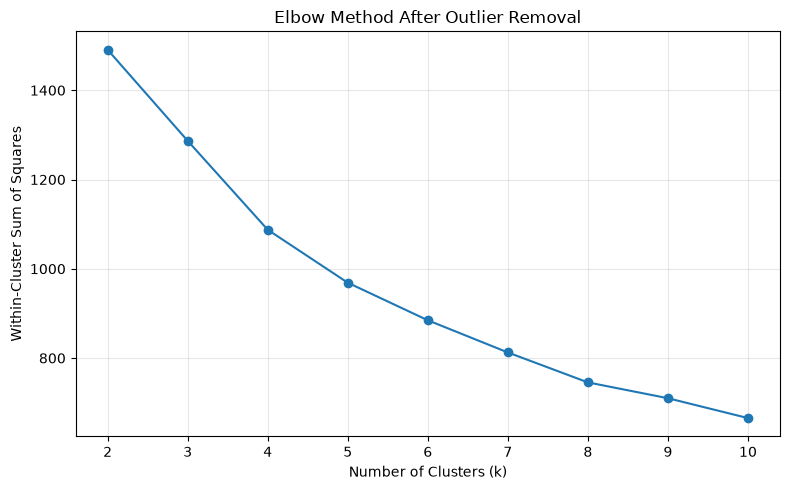

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_final,
    final_inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method After Outlier Removal")
plt.xticks(k_values_final)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

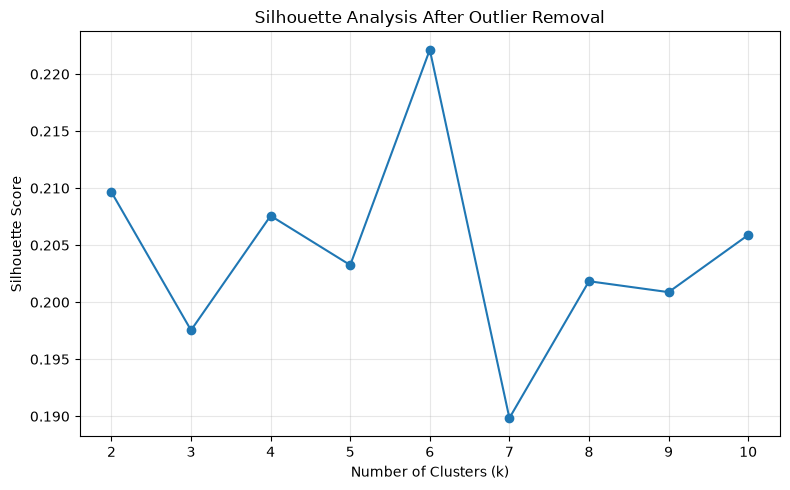

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_final,
    final_silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis After Outlier Removal")
plt.xticks(k_values_final)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# ---------------------------------------
# Final K-Means Clustering (k = 4)
# ---------------------------------------

final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

final_cluster_labels = final_kmeans.fit_predict(X_cluster_scaled_final)

In [42]:
final_cluster_results = cluster_analysis_df.copy()

final_cluster_results["Cluster"] = final_cluster_labels

In [43]:
# ---------------------------------------
# Final Cluster Summary
# ---------------------------------------

final_cluster_summary = (
    final_cluster_results
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

# Add cluster sizes
cluster_sizes = final_cluster_results.groupby("Cluster").size()

final_cluster_summary.insert(0, "Cluster Size", cluster_sizes)

display(final_cluster_summary)

,Cluster Size,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
Cluster,,,,,,,,,,,,,,
0,54,217.31,19.10,63.56,5225.57,1.19,103.86,5.65,31.06,7.73,89.39,6.94,14143.50,36.67
1,77,2279.84,41.06,78.85,51408.64,5.00,3642.86,9.23,67.40,54.00,225.99,8.01,392084.48,39.81
2,3,1680.54,39.81,83.31,99361.75,2.81,4050.81,5.15,98.07,104.24,6113.80,9.80,539082.85,50.83
3,103,1064.61,29.62,74.12,20443.73,2.03,565.51,6.69,63.24,32.63,204.70,13.84,163144.28,49.63


In [44]:
final_cluster_results.loc[
    final_cluster_results["Cluster"] == 2,
    ["country"]
]

,country
80,Gibraltar
93,Hong Kong
192,Singapore


In [45]:
final_cluster_results.loc[
    final_cluster_results["Cluster"] == 2,
    [
        "country",
        "gdp_per_capita",
        "population_density",
        "hospital_beds_per_thousand",
        "health_expenditure_pct_gdp",
        "people_fully_vaccinated_per_hundred",
        "median_age"
    ]
]

,country,gdp_per_capita,population_density,hospital_beds_per_thousand,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,median_age
80,Gibraltar,NaN,3685.800000,NaN,NaN,110.188410,38.948002
93,Hong Kong,66153.976562,7060.095238,NaN,NaN,91.124664,45.591000
192,Singapore,132569.531250,7595.495822,2.81,5.145997,92.899060,34.877998


In [46]:
all_countries = pd.concat(
    [final_cluster_results, cluster_outliers],
    ignore_index=True
)

In [47]:
# ---------------------------------------
# K-Means Clustering (k = 6)
# ---------------------------------------

kmeans6 = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

cluster_labels6 = kmeans6.fit_predict(X_cluster_scaled_final)

In [48]:
# ---------------------------------------
# Cluster Results (k = 6)
# ---------------------------------------

cluster_results6 = cluster_analysis_df.copy()

cluster_results6["Cluster"] = cluster_labels6

In [49]:
# ---------------------------------------
# Cluster Summary (k = 6)
# ---------------------------------------

cluster_summary6 = (
    cluster_results6
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

# Add cluster sizes
cluster_sizes6 = cluster_results6.groupby("Cluster").size()

cluster_summary6.insert(0, "Cluster Size", cluster_sizes6)

display(cluster_summary6)

,Cluster Size,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
Cluster,,,,,,,,,,,,,,
0,44,112.79,18.53,62.96,4712.22,1.16,74.11,4.85,26.07,6.38,90.79,6.59,7116.29,36.75
1,46,2164.84,40.07,79.54,56282.46,3.26,4467.27,10.48,70.36,58.43,232.95,8.02,392363.82,38.70
2,22,2808.14,40.62,76.31,37884.01,7.47,1861.67,8.21,58.03,39.80,146.09,8.01,294991.34,40.28
3,94,1163.97,31.08,74.13,15949.88,2.10,592.25,6.63,60.72,31.10,198.61,9.92,182932.63,50.44
4,28,756.40,27.60,73.65,31119.19,1.94,828.81,7.01,71.16,38.20,231.10,21.02,205129.11,43.09
5,3,1680.54,39.81,83.31,99361.75,2.81,4050.81,5.15,98.07,104.24,6113.80,9.80,539082.85,50.83


In [50]:
cluster_results6.loc[
    cluster_results6["Cluster"] == 5,
    ["country"]
]

,country
80,Gibraltar
93,Hong Kong
192,Singapore


## Selection of the Final Clustering Solution

Following the removal of Monaco and Macao, K-Means clustering was reevaluated using four- and six-cluster solutions. Although the six-cluster solution produced the highest silhouette score, inspection of the cluster profiles showed that the additional clusters primarily subdivided larger groups rather than revealing substantially different country types.

The four-cluster solution provided a more parsimonious and interpretable representation of the data. Three broad clusters captured most countries, while a fourth cluster consistently grouped Gibraltar, Hong Kong, and Singapore. This small cluster remained unchanged in both the four- and six-cluster solutions, indicating that it represents a stable group of highly urbanized jurisdictions rather than an artifact of the selected number of clusters.

Based on the elbow method, silhouette analysis, cluster stability, and interpretability, the four-cluster solution was selected for the remainder of the analysis.

In [51]:
# ---------------------------------------
# Final Clustering Solution (k = 4)
# ---------------------------------------

# The final k = 4 model was fitted after removing Monaco and Macao.
# These objects will be used throughout the remainder of the notebook.

final_cluster_summary = (
    final_cluster_results
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_sizes = final_cluster_results.groupby("Cluster").size()

final_cluster_summary.insert(
    0,
    "Cluster Size",
    cluster_sizes
)

display(final_cluster_summary)

,Cluster Size,total_deaths_per_million,median_age,life_expectancy,gdp_per_capita,hospital_beds_per_thousand,health_expenditure_per_capita,health_expenditure_pct_gdp,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,population_density,diabetes_prevalence,total_cases_per_million,stringency_index
Cluster,,,,,,,,,,,,,,
0,54,217.31,19.10,63.56,5225.57,1.19,103.86,5.65,31.06,7.73,89.39,6.94,14143.50,36.67
1,77,2279.84,41.06,78.85,51408.64,5.00,3642.86,9.23,67.40,54.00,225.99,8.01,392084.48,39.81
2,3,1680.54,39.81,83.31,99361.75,2.81,4050.81,5.15,98.07,104.24,6113.80,9.80,539082.85,50.83
3,103,1064.61,29.62,74.12,20443.73,2.03,565.51,6.69,63.24,32.63,204.70,13.84,163144.28,49.63


In [52]:
pd.crosstab(
    final_cluster_results["continent"],
    final_cluster_results["Cluster"]
)

Cluster,0,1,2,3
continent,,,,
Africa,42,1,0,15
Asia,6,11,2,30
Europe,0,47,1,3
North America,2,15,0,24
Oceania,3,2,0,19
South America,1,1,0,12


In [53]:
# ---------------------------------------
# Prepare Data for Cluster Map
# ---------------------------------------

cluster_map = final_cluster_results.copy()

# Convert cluster labels to strings
cluster_map["Cluster"] = cluster_map["Cluster"].astype(str)

# Add excluded outliers
excluded = cluster_outliers.copy()
excluded["Cluster"] = "Excluded"

# Combine clustered countries with excluded outliers
cluster_map = pd.concat(
    [cluster_map, excluded],
    ignore_index=True
)

# Add ISO country codes
cluster_map = cluster_map.merge(
    analysis_df[["country", "code"]].drop_duplicates(),
    on="country",
    how="left"
)

# Replace cluster numbers with descriptive names
cluster_map["Cluster"] = cluster_map["Cluster"].replace({
    "0": "Cluster 0: Younger, Lower-Income",
    "1": "Cluster 1: Older, High-Income",
    "2": "Cluster 2: Dense Urban Jurisdictions",
    "3": "Cluster 3: Mixed Middle-Income",
    "Excluded": "Excluded Outliers",
})


# Check for missing ISO codes
cluster_map.loc[
    cluster_map["code"].isna(),
    ["country"]
]

,country


## Cluster Interpretation

The K-Means analysis identified four distinct groups of countries based on demographic, economic, healthcare, and vaccination characteristics. These clusters represent countries with similar underlying profiles rather than geographic proximity.

- **Cluster 0 – Younger, Lower-Income Countries:** Countries in this cluster have the youngest populations, lowest GDP per capita, shortest life expectancy, fewest hospital beds, and the lowest vaccination rates. They also experienced the lowest reported COVID-19 case and mortality rates.

- **Cluster 1 – Older, High-Income Countries:** This cluster contains countries with older populations, higher income levels, longer life expectancy, and more developed healthcare infrastructure. These countries reported the highest COVID-19 case rates and mortality, reflecting both older populations and extensive disease surveillance.

- **Cluster 2 – Dense Urban Jurisdictions:** This small cluster consists of three highly urbanized, high-income jurisdictions characterized by exceptionally high population density, very high vaccination coverage, and the highest reported case rates. Despite widespread transmission, mortality remained somewhat lower than in Cluster 1.

- **Cluster 3 – Mixed Middle-Income Countries:** Countries in this cluster exhibit intermediate demographic, economic, and healthcare characteristics. COVID-19 case and mortality rates generally fell between those observed in the younger, lower-income countries and the older, wealthier countries.

The following map illustrates the geographic distribution of these four country clusters.

### Clusters on PCA1 and PCA2

In [54]:
print(X_pca.shape)
print(final_cluster_results.shape)
print(analysis_df.shape)

(239, 8)
(237, 16)
(239, 22)


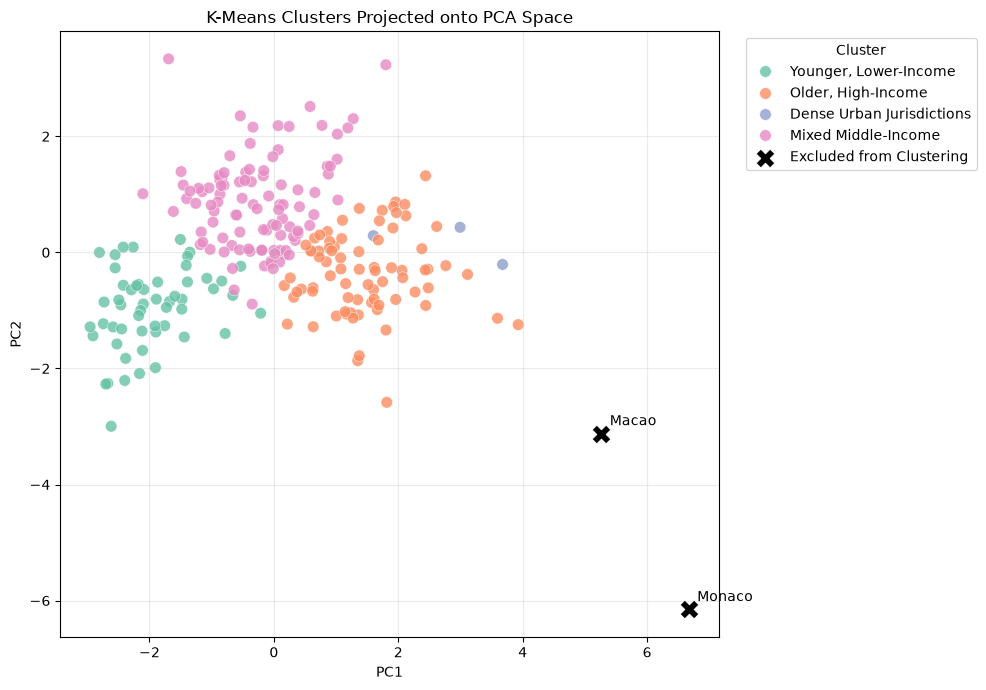

In [55]:
# ---------------------------------------
# Figure 5. PCA Clusters
# ---------------------------------------

# PCA coordinates for all 239 countries
pca_scores = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
)

# Attach country names in the same row order used for PCA
pca_scores["country"] = analysis_df["country"].reset_index(drop=True)

# Merge the 237 final cluster assignments by country
pca_scores = pca_scores.merge(
    final_cluster_results[["country", "Cluster"]],
    on="country",
    how="left",
)

cluster_labels = {
    0: "Younger, Lower-Income",
    1: "Older, High-Income",
    2: "Dense Urban Jurisdictions",
    3: "Mixed Middle-Income",
}

pca_scores["Cluster Label"] = pca_scores["Cluster"].map(cluster_labels)

clustered_scores = pca_scores[pca_scores["Cluster Label"].notna()].copy()
excluded_scores = pca_scores[pca_scores["Cluster Label"].isna()].copy()

fig_pca, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=clustered_scores,
    x="PC1",
    y="PC2",
    hue="Cluster Label",
    hue_order=[
        "Younger, Lower-Income",
        "Older, High-Income",
        "Dense Urban Jurisdictions",
        "Mixed Middle-Income",
    ],
    palette="Set2",
    s=70,
    edgecolor="white",
    linewidth=0.4,
    alpha=0.8,
    ax=ax,
)

ax.scatter(
    excluded_scores["PC1"],
    excluded_scores["PC2"],
    marker="X",
    s=180,
    color="black",
    edgecolor="white",
    linewidth=0.6,
    label="Excluded from Clustering",
    zorder=5,
)

for _, row in excluded_scores.iterrows():
    ax.annotate(
        row["country"],
        xy=(row["PC1"], row["PC2"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_title("K-Means Clusters Projected onto PCA Space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)

ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.03, 1),
    loc="upper left",
)

fig_pca.tight_layout()

fig_pca.savefig(
    FIGURE_DIR / "Figure5_PCA_Clusters.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

The first two principal components provide a useful two-dimensional representation of the standardized country characteristics while preserving much of the variation present in the original dataset. Countries assigned to the four K-Means clusters occupy largely distinct regions of the PCA space, indicating that the clustering algorithm identified meaningful structure in the data.

Monaco and Macao appear as clear outliers, reflecting their unique demographic and economic characteristics. Because these two jurisdictions are substantially different from the remaining countries, they were excluded from the K-Means analysis to prevent them from disproportionately influencing the cluster solution.

Although some overlap exists between clusters, this is expected because the visualization represents only the first two principal components, whereas K-Means clustering was performed using the full multidimensional feature space. Overall, the PCA projection provides visual support that the identified clusters represent distinct groups of countries with differing demographic, economic, healthcare, and vaccination characteristics.

### Geographical distribution of clusters

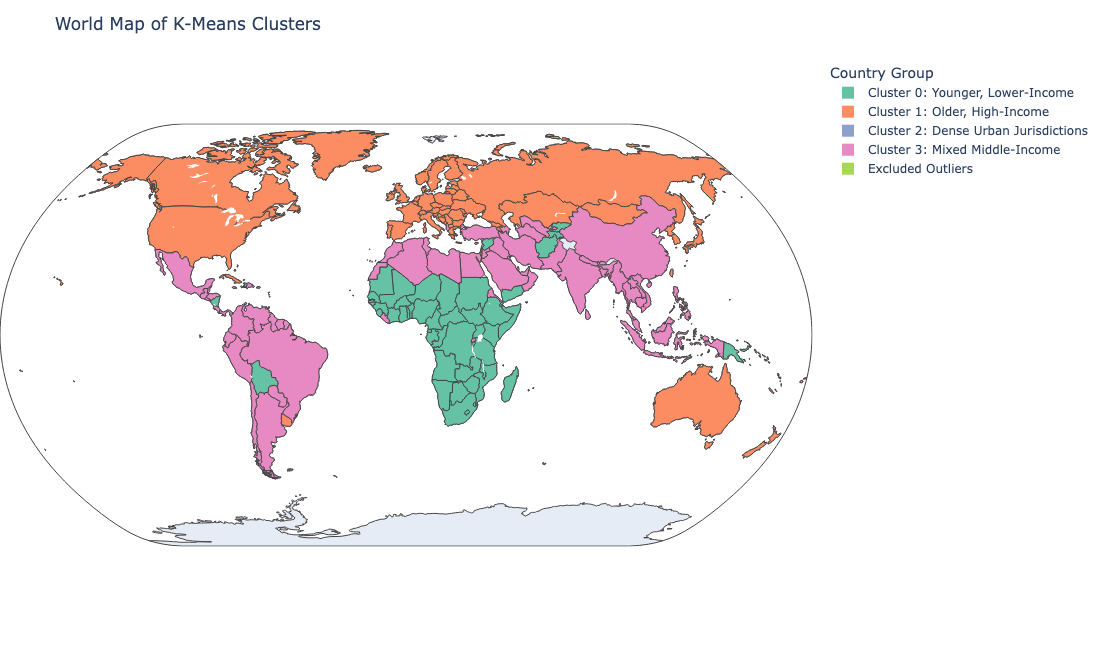

In [58]:
# ---------------------------------------
# Figure 4A. World Map of Final Clusters
#   NOTE: this is 4A because I already named later figures and Capstone 2 already had figure 4.
# ---------------------------------------

# Full descriptive labels for notebook, report, and Streamlit
report_category_order = [
    "Cluster 0: Younger, Lower-Income",
    "Cluster 1: Older, High-Income",
    "Cluster 2: Dense Urban Jurisdictions",
    "Cluster 3: Mixed Middle-Income",
    "Excluded Outliers",
]

fig_cluster_map = px.choropleth(
    cluster_map,
    locations="code",
    color="Cluster",
    hover_name="country",
    hover_data={
        "continent": True,
        "Cluster": False,
        "code": False,
    },
    projection="natural earth",
    title="World Map of K-Means Clusters",
    color_discrete_sequence=px.colors.qualitative.Set2,
    category_orders={"Cluster": report_category_order},
)

fig_cluster_map.update_layout(
    legend_title_text="Country Group",
    legend=dict(
        orientation="v",
        x=1.02,
        xanchor="left",
        y=1.0,
        yanchor="top",
    ),
    margin=dict(
        l=0,
        r=220,
        t=60,
        b=40,
    ),
    height=650,
)

# Display the full interactive version in the notebook
fig_cluster_map.show()

# Save the interactive version for reuse or Streamlit
fig_cluster_map.write_html(
    FIGURE_DIR / "Figure4A_KMeans_Clusters_Map.html"
)

# Save the full descriptive version for reports
fig_cluster_map.write_image(
    FIGURE_DIR / "Figure4A_KMeans_Clusters_Map.png",
    width=1600,
    height=900,
    scale=2,
)

# ---------------------------------------
# Create a Compact Slide Version
# ---------------------------------------

slide_cluster_map = cluster_map.copy()

slide_cluster_map["Cluster"] = slide_cluster_map["Cluster"].replace({
    "Cluster 0: Younger, Lower-Income": "Cluster 0",
    "Cluster 1: Older, High-Income": "Cluster 1",
    "Cluster 2: Dense Urban Jurisdictions": "Cluster 2",
    "Cluster 3: Mixed Middle-Income": "Cluster 3",
    "Excluded Outliers": "Excluded",
})

slide_category_order = [
    "Cluster 0",
    "Cluster 1",
    "Cluster 2",
    "Cluster 3",
    "Excluded",
]

fig_cluster_map_slide = px.choropleth(
    slide_cluster_map,
    locations="code",
    color="Cluster",
    hover_name="country",
    projection="natural earth",
   # title="Final K-Means Country Clusters",
    title="World Map of K-Means Clusters",
    color_discrete_sequence=px.colors.qualitative.Set2,
    category_orders={"Cluster": slide_category_order},
)

fig_cluster_map_slide.update_layout(
    legend_title_text="Country Group",
    legend=dict(
        orientation="h",
        x=0.5,
        xanchor="center",
        y=-0.06,
        yanchor="top",
    ),
    margin=dict(
        l=0,
        r=0,
        t=60,
        b=110,
    ),
    height=650,
)

# Save a compact version for presentation slides
fig_cluster_map_slide.write_image(
    FIGURE_DIR / "Figure4A_KMeans_Clusters_Map_Slide.png",
    width=1600,
    height=900,
    scale=2,
)

In [56]:
import sys
import plotly
import plotly.express as px
from importlib.metadata import version
import kaleido

print("Python:", sys.executable)
print("Plotly:", plotly.__version__)
print("Kaleido:", version("kaleido"))

Python: /Users/papa/miniforge3/envs/ds/bin/python
Plotly: 6.8.0
Kaleido: 1.3.0


In [57]:


chrome_path = kaleido.get_chrome_sync()
print(chrome_path)

/Users/papa/Library/Application Support/choreographer/deps/chrome-mac-x64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing


In [59]:
cluster_summary_table = (
    final_cluster_results
    .groupby("Cluster")
    .agg(
        Countries=("country", "count"),
        Median_Age=("median_age", "median"),
        GDP_per_Capita=("gdp_per_capita", "median"),
        Life_Expectancy=("life_expectancy", "median"),
        Hospital_Beds=("hospital_beds_per_thousand", "median"),
        Vaccinated=("people_fully_vaccinated_per_hundred", "median"),
        Cases_per_Million=("total_cases_per_million", "median"),
        Deaths_per_Million=("total_deaths_per_million", "median"),
        Population_Density=("population_density", "median"),
    )
    .round(1)
)

cluster_summary_table.index = [
    "Cluster 0",
    "Cluster 1",
    "Cluster 2",
    "Cluster 3",
]

cluster_summary_table


,Countries,Median_Age,GDP_per_Capita,Life_Expectancy,Hospital_Beds,Vaccinated,Cases_per_Million,Deaths_per_Million,Population_Density
Cluster 0,54,18.2,3802.1,64.6,0.8,29.6,4535.4,74.8,56.4
Cluster 1,77,41.5,47338.8,79.9,4.3,70.0,395005.7,2158.8,105.1
Cluster 2,3,38.9,99361.8,83.5,2.8,92.9,539082.9,1680.5,7060.1
Cluster 3,103,29.3,15661.8,74.5,1.8,64.4,123764.1,845.0,122.7


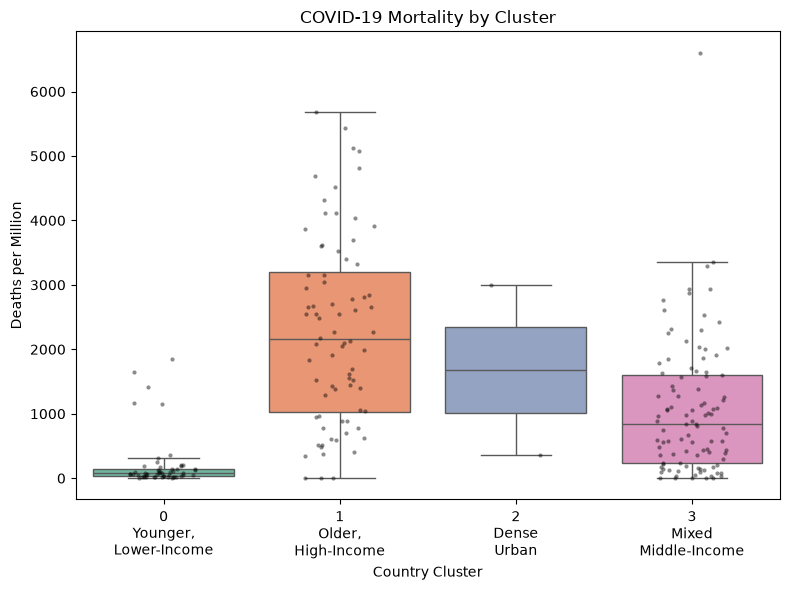

In [60]:
# ---------------------------------------
# Figure X. COVID-19 Mortality by Cluster
# ---------------------------------------

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=final_cluster_results,
    x="Cluster",
    y="total_deaths_per_million",
    hue="Cluster",
    palette="Set2",
    dodge=False,
    showfliers=False,
    legend=False,
)

# Individual countries
sns.stripplot(
    data=final_cluster_results,
    x="Cluster",
    y="total_deaths_per_million",
    color="black",
    alpha=0.45,
    size=3,
    jitter=0.2,
)

plt.title("COVID-19 Mortality by Cluster")
plt.xlabel("Country Cluster")
plt.ylabel("Deaths per Million")

plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "0\nYounger,\nLower-Income",
        "1\nOlder,\nHigh-Income",
        "2\nDense\nUrban",
        "3\nMixed\nMiddle-Income",
    ],
)

# Save the full descriptive version for reports
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "Figure6_COVID_Mortality_by_Cluster.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## COVID-19 Outcomes by Cluster

To evaluate whether the identified clusters are associated with different pandemic outcomes, the distribution of COVID-19 mortality is compared across the four groups. While the clustering algorithm did not use mortality directly as a clustering feature, differences in deaths per million provide insight into whether countries with similar demographic, economic, and healthcare characteristics experienced similar pandemic impacts.

### Interpretation

COVID-19 mortality differs substantially across the four country clusters. Cluster 0, composed primarily of younger and lower-income countries, generally experienced the lowest reported deaths per million. In contrast, Cluster 1, which includes older and higher-income countries, shows substantially higher mortality levels and considerable variation across countries.

Cluster 2 contains only a small number of densely populated urban jurisdictions, so its mortality distribution should be interpreted cautiously. Cluster 3, representing a broader group of middle-income countries, generally falls between Clusters 0 and 1 but also exhibits wide variability.

These differences suggest that the demographic, economic, healthcare, and vaccination characteristics used to define the clusters are associated with distinct pandemic outcomes. However, the boxplot is descriptive and does not establish that cluster membership caused the observed differences in mortality. Reported mortality may also reflect differences in surveillance, testing, reporting practices, epidemic timing, and other factors not included in the clustering analysis.

In [61]:
# ---------------------------------------
# Save Final Cluster Assignments
# ---------------------------------------

cluster_results_path = (
    PROCESSED_DATA_DIR / "covid_cluster_assignments.csv"
)

final_cluster_results.to_csv(
    cluster_results_path,
    index=False,
)

print(
    f"Final cluster assignments saved: "
    f"{final_cluster_results.shape[0]:,} countries"
)

Final cluster assignments saved: 237 countries
